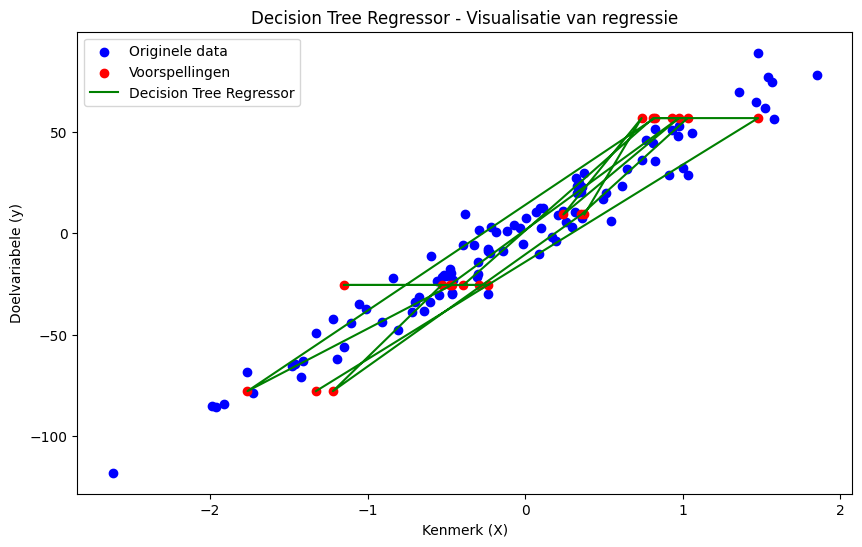

Mean Squared Error: 404.50


In [23]:
# Importeren van benodigde libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression

# Stap 1: Genereer een dataset
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

# Stap 2: Verdeel de data in trainings- en testsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Stap 3: Maak een DecisionTreeRegressor model
model = DecisionTreeRegressor(random_state=42, max_depth=2)

# Stap 4: Train het model
model.fit(X_train, y_train)

# Stap 5: Maak voorspellingen
y_pred = model.predict(X_test)

# Stap 6: Visualiseer de originele data en de regressiecurve
plt.figure(figsize=(10,6))
plt.scatter(X, y, color='blue', label='Originele data')  # Scatter plot van originele data
plt.scatter(X_test, y_pred, color='red', label='Voorspellingen')  # Voorspellingen
plt.plot(X_test, y_pred, color='green', label='Decision Tree Regressor')  # Decision tree lijn
plt.title('Decision Tree Regressor - Visualisatie van regressie')
plt.xlabel('Kenmerk (X)')
plt.ylabel('Doelvariabele (y)')
plt.legend()
plt.show()

# Stap 7: Beoordeel de performance van het model
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')


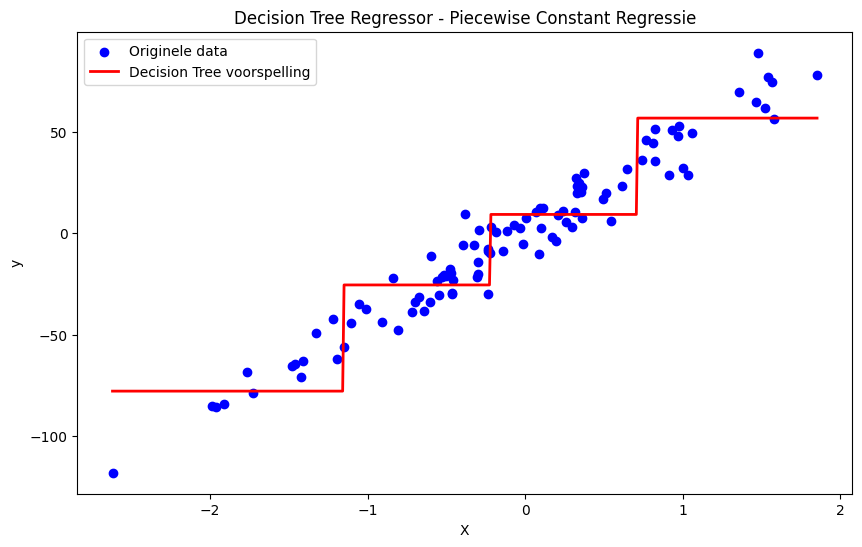

In [24]:
# Visualiseer Decision Tree correct
plt.figure(figsize=(10,6))
plt.scatter(X, y, color='blue', label='Originele data')

# Grid maken
X_grid = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
y_grid_pred = model.predict(X_grid)

# Trapvormige lijn plotten
plt.plot(X_grid, y_grid_pred, color='red', linewidth=2, label='Decision Tree voorspelling')

plt.title('Decision Tree Regressor - Piecewise Constant Regressie')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


In [25]:
import pandas as pd
import numpy as np

tree_ = model.tree_

feature_names = ["X"]  # je enige feature uit make_regression

nodes = []
for node_id in range(tree_.node_count):
    feature_idx = tree_.feature[node_id]
    
    # In sklearn: feature_idx < 0 betekent LEAF (meestal -2)
    if feature_idx < 0:
        feature_name = "LEAF"
        threshold = np.nan
    else:
        feature_name = feature_names[feature_idx]
        threshold = tree_.threshold[node_id]
    
    nodes.append({
        "node_id": node_id,
        "feature_used": feature_name,
        "threshold": threshold,
        "samples": tree_.n_node_samples[node_id],
        "impurity": tree_.impurity[node_id],
    })

overview = pd.DataFrame(nodes)
print(overview)


   node_id feature_used  threshold  samples     impurity
0        0            X  -0.222724       80  1673.796125
1        1            X  -1.151271       37   735.462397
2        2         LEAF        NaN       10   260.825704
3        3         LEAF        NaN       27   170.721826
4        4            X   0.707562       43   629.962752
5        5         LEAF        NaN       30   117.522865
6        6         LEAF        NaN       13   238.795932


Lineaire regressie
  MSE: 3.113
  R² : 0.028

DecisionTreeRegressor (max_depth=3)
  MSE: 0.692
  R² : 0.784



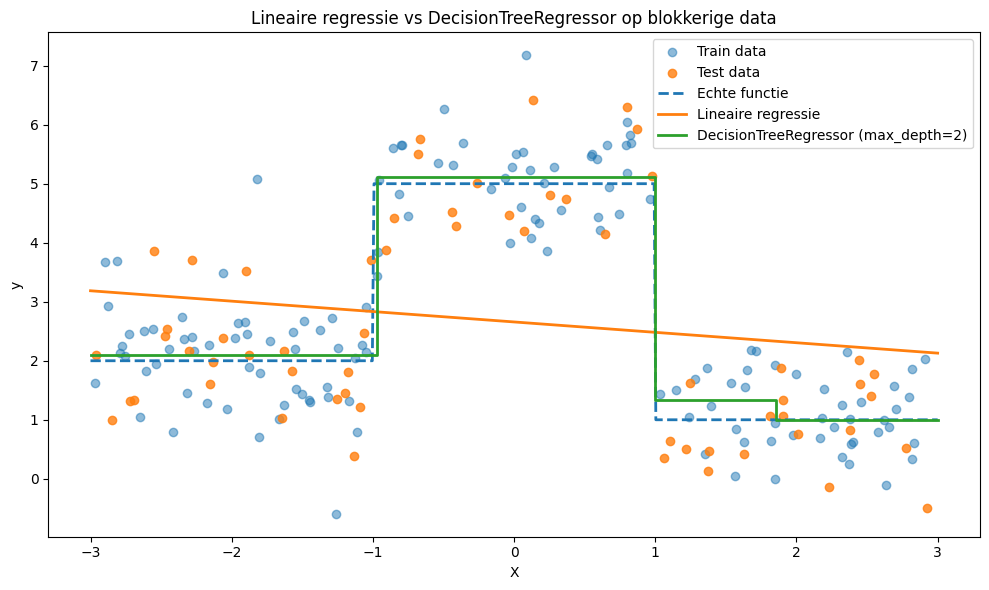

In [26]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ============================
# 1. Data genereren
# ============================
np.random.seed(42)

n_samples = 200

# X-waarden: gelijkmatig tussen -3 en 3
X = np.random.uniform(-3, 3, size=(n_samples, 1))

# Echte onderliggende (blokkerige) functie
def true_function(x):
    """
    Piecewise constante relatie:
    - x < -1      -> y = 2
    - -1 <= x < 1 -> y = 5
    - x >= 1      -> y = 1
    """
    return np.where(
        x < -1,
        2,
        np.where(x < 1, 5, 1)
    )

y_true = true_function(X)

# Ruis toevoegen
noise = np.random.normal(loc=0.0, scale=0.8, size=y_true.shape)
y = y_true + noise

# Train/test-split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ============================
# 2. Modellen definiëren en trainen
# ============================

# Lineaire regressie
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Decision tree regressie (max_depth = 3 kun je eventueel naar 2 veranderen)
tree = DecisionTreeRegressor(max_depth=2, random_state=42)
tree.fit(X_train, y_train)

# ============================
# 3. Evaluatie op testset
# ============================
models = [
    ("Lineaire regressie", lin_reg),
    ("DecisionTreeRegressor (max_depth=3)", tree)
]

for name, model in models:
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(name)
    print(f"  MSE: {mse:.3f}")
    print(f"  R² : {r2:.3f}")
    print()

# ============================
# 4. Visualisatie
# ============================

# Fijn rooster voor mooie lijnen
X_grid = np.linspace(-3, 3, 500).reshape(-1, 1)
y_lin_grid = lin_reg.predict(X_grid)
y_tree_grid = tree.predict(X_grid)
y_true_grid = true_function(X_grid)

plt.figure(figsize=(10, 6))

# Data punten
plt.scatter(X_train, y_train, alpha=0.5, label="Train data")
plt.scatter(X_test, y_test, alpha=0.8, label="Test data")

# Echte onderliggende functie (stippellijn)
plt.plot(X_grid, y_true_grid, linestyle="--", linewidth=2, label="Echte functie")

# Lineaire regressie (rechte lijn)
plt.plot(X_grid, y_lin_grid, linewidth=2, label="Lineaire regressie")

# Decision tree (trapvormig, met step-plot)
plt.step(
    X_grid.ravel(),
    y_tree_grid,
    where="mid",
    linewidth=2,
    label="DecisionTreeRegressor (max_depth=2)"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Lineaire regressie vs DecisionTreeRegressor op blokkerige data")
plt.legend()
plt.tight_layout()
plt.show()
